## Memo Pilot Test

Create a preliminary implementation (pilot) of the research design you outlined in your memo of this week. Use the techniques and frameworks introduced in this assignment to demonstrate how your proposed approach can be operationalized.

## Imports

In [ ]:
# Imports
import re
import pandas as pd
import numpy as np
from typing import List
import unicodedata

!pip install gensim
from gensim.models import Word2Vec

# For more advanced text processing
try:
    import emoji
except ImportError:
    print("Installing emoji package...")
    %pip install emoji
    import emoji

## Loading data

In [ ]:
# First, let's get the data stored on drive
!pip -q install gdown

!gdown --fuzzy "https://drive.google.com/file/d/1rASjDiIQ9WeTW9ZfIfqWNjO-S_qKmq5H/view?usp=sharing" -O /content/original_content_en_1mio.csv

path_en = "/content/original_content_en_1mio.csv"
path_de = "/content/original_content_de_1mio.csv"
msg_en = pd.read_csv(path_en)
msg_de = pd.read_csv(path_de)

Downloading...
From (original): https://drive.google.com/uc?id=1rASjDiIQ9WeTW9ZfIfqWNjO-S_qKmq5H
From (redirected): https://drive.google.com/uc?id=1rASjDiIQ9WeTW9ZfIfqWNjO-S_qKmq5H&confirm=t&uuid=626975f9-5374-417f-9b8e-f4bfadd37962
To: /content/original_content_en_1mio.csv
100% 364M/364M [00:03<00:00, 95.4MB/s] 


## Cleaning Text

In [ ]:
def clean_text_vectorized(series: pd.Series) -> pd.Series:
    """
    Vectorized text cleaning for word2vec training.
    Handles English and German text, removes emojis, URLs, and special characters.
    Uses pandas vectorized string operations for maximum performance on large datasets.
    
    Args:
        series: Input pandas Series containing text
        
    Returns:
        Cleaned pandas Series
    """
    # Handle NaN and non-string values
    text = series.fillna('').astype(str)
    
    # Convert to lowercase (vectorized)
    text = text.str.lower()
    
    # Remove URLs (vectorized regex operations)
    # http/https URLs
    text = text.str.replace(
        r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+',
        '', regex=True
    )
    # www URLs
    text = text.str.replace(
        r'www\.(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+',
        '', regex=True
    )
    # t.me links
    text = text.str.replace(r't\.me/[^\s]+', '', regex=True)
    # bit.ly links
    text = text.str.replace(r'bit\.ly/[^\s]+', '', regex=True)
    # cutt.ly links
    text = text.str.replace(r'cutt\.ly/[^\s]+', '', regex=True)
    
    # Remove emojis (apply is still needed for emoji library, but only on non-empty strings)
    # For better performance, we filter empty strings before applying emoji removal
    non_empty_mask = text.str.len() > 0
    if non_empty_mask.any():
        text.loc[non_empty_mask] = text.loc[non_empty_mask].apply(
            lambda x: emoji.replace_emoji(x, replace='') if x else ''
        )
    
    # Remove email addresses (vectorized)
    text = text.str.replace(r'\S+@\S+', '', regex=True)
    
    # Remove mentions (vectorized)
    text = text.str.replace(r'@\w+', '', regex=True)
    
    # Remove hashtags symbols (but keep the text after # for potential semantic value)
    text = text.str.replace(r'#', '', regex=True)
    
    # Remove special characters and symbols but keep German umlauts and ß (vectorized)
    # Keep: a-z, A-Z, ä, ö, ü, Ä, Ö, Ü, ß, and spaces
    text = text.str.replace(r'[^a-zA-ZäöüÄÖÜß\s]', ' ', regex=True)
    
    # Remove extra whitespace (vectorized)
    text = text.str.replace(r'\s+', ' ', regex=True)
    
    # Strip leading/trailing whitespace (vectorized)
    text = text.str.strip()
    
    return text


def preprocess_dataframe_for_word2vec(df: pd.DataFrame, 
                                       text_column: str = 'content',
                                       min_length: int = 3) -> pd.DataFrame:
    """
    Preprocess a dataframe for word2vec training using vectorized operations.
    Highly scalable for 1M+ messages - uses pandas vectorized string operations
    instead of .apply() for dramatic performance improvements.
    
    Args:
        df: Input dataframe
        text_column: Name of the column containing text
        min_length: Minimum length of cleaned text to keep (in characters)
        
    Returns:
        Dataframe with cleaned text
    """
    # Create a copy to avoid modifying the original
    df_clean = df.copy()
    
    # Apply cleaning function using vectorized operations
    print(f"Cleaning {len(df_clean)} messages...")
    df_clean['cleaned_text'] = clean_text_vectorized(df_clean[text_column])
    
    # Remove empty or very short texts (vectorized comparison)
    initial_count = len(df_clean)
    df_clean = df_clean[df_clean['cleaned_text'].str.len() >= min_length]
    removed_count = initial_count - len(df_clean)
    print(f"Removed {removed_count} messages with length < {min_length} characters")
    
    # Remove duplicates (optional but recommended for better embeddings)
    initial_count = len(df_clean)
    df_clean = df_clean.drop_duplicates(subset=['cleaned_text'])
    removed_count = initial_count - len(df_clean)
    print(f"Removed {removed_count} duplicate messages")
    
    print(f"Final dataset size: {len(df_clean)} messages")
    
    return df_clean


def tokenize_for_word2vec(df: pd.DataFrame, 
                          text_column: str = 'cleaned_text') -> List[List[str]]:
    """
    Tokenize cleaned text for word2vec training using vectorized operations.
    Returns a list of tokenized sentences (list of lists).
    
    Args:
        df: Dataframe with cleaned text
        text_column: Name of column containing cleaned text
        
    Returns:
        List of tokenized sentences
    """
    print("Tokenizing messages...")
    # Simple whitespace tokenization (vectorized - already efficient)
    tokenized_sentences = df[text_column].str.split().tolist()
    
    # Remove empty lists (list comprehension is efficient for this operation)
    tokenized_sentences = [sent for sent in tokenized_sentences if sent]
    
    print(f"Total sentences for training: {len(tokenized_sentences)}")
    
    # Print some statistics using numpy for efficiency
    word_counts = [len(sent) for sent in tokenized_sentences]
    word_counts_array = np.array(word_counts)
    print(f"Average words per message: {word_counts_array.mean():.2f}")
    print(f"Median words per message: {np.median(word_counts_array):.2f}")
    print(f"Max words per message: {word_counts_array.max()}")
    
    return tokenized_sentences


Installing emoji package...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 19.6 MB/s eta 0:00:00


In [ ]:
# Step 1: Clean the dataframe
clean_de = preprocess_dataframe_for_word2vec(msg_de, text_column='content', min_length=10)
clean_en = preprocess_dataframe_for_word2vec(msg_en, text_column='content', min_length=10)
clean_de.head(10)

Cleaning 1000000 messages...
Removed 1771 messages with length < 50 characters
Removed 220900 duplicate messages
Final dataset size: 777329 messages


,posts_id,content,cleaned_text
0,34338095,WHO IS PULLING THE STRINGS 💥🐸🇺🇸 SHARE!!\n\nJOI...,who is pulling the strings share join be ready...
1,8142176,YOU'VE BEEN SELECTED TO GET YOUR VERY OWN TRUM...,you ve been selected to get your very own trum...
2,34345426,💥BQQQQQQQM💥 THE ENDGAME - EXPOSED 🍿🐸🇺🇸 SHARE!!...,bqqqqqqqm the endgame exposed share join get p...
3,7130377,Real America with Dan Ball has a new set desig...,real america with dan ball has a new set desig...
4,18556553,💥BQQQQQQQMMM💥 CONNECT THE DOTS - PATRIOTS HAVE...,bqqqqqqqmmm connect the dots patriots have it ...
5,33933069,The Revenge is coming!\n\nJohn McAfee is alive...,the revenge is coming john mcafee is alive and...
6,35168422,It’s time for SGAnon! 🇺🇸\n\nThe channel you we...,it s time for sganon the channel you were all ...
7,35463932,LIVE IN 6 HOURS! \n \nNO DELAYS AND NO STOPPIN...,live in hours no delays and no stopping this t...
8,33729614,It is obvious everyone attending the Trump Ral...,it is obvious everyone attending the trump ral...
9,35421432,💣SHOCKING NEWS💣\n\n🆘Edward Snowden is ready to...,shocking news edward snowden is ready to publi...


In [ ]:
# Add an extra step: replacing entity variations with a regularized name (e.g. joe_biden)
# Check if names appear at beginning or end of another string; in which case to replace too and add
# a space after/before; or if appear without a space in the entity variation (e.g., joebiden)
# Any checks should be case insensitive

In [ ]:
# Step 2: Tokenize for word2vec
sent_de = tokenize_for_word2vec(clean_de, text_column='cleaned_text')
sent_en = tokenize_for_word2vec(clean_en, text_column='cleaned_text')


Tokenizing messages...
Total sentences for training: 777329
Average words per message: 54.20
Median words per message: 34.00
Max words per message: 857
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 81.3 MB/s eta 0:00:00:00:010:01m


In [ ]:
# Step 3: Train word2vec model (example)
# do one for english and german with good parameter values 
model = Word2Vec(sentences=sentences, 
                 vector_size=100,      # dimensionality of word vectors
                 window=5,              # context window size
                 min_count=5,           # ignore words with frequency < 5
                 workers=4,             # number of parallel threads
                 sg=0,                  # 0=CBOW, 1=Skip-gram
                 epochs=10)

# Example: View the cleaned data
# print("\nExample of original vs cleaned text:")
# print("Original:", df.iloc[0]['content'][:100])
# print("Cleaned:", df_clean.iloc[0]['cleaned_text'][:100])

In [ ]:
def similar_words_df(model, word, topn=10):
    return pd.DataFrame(
        model.wv.most_similar(word, topn=topn),
        columns=["word", "cosine_similarity"]
    )

display(similar_words_df(model, "trump"))

,word,cosine_similarity
0,djt,0.888625
1,joebiden,0.746850
2,kriss,0.692919
3,tump,0.683220
4,trumps,0.681746
5,rumsfeld,0.664323
6,bolsonaro,0.662754
7,biden,0.643829
8,potus,0.626496
9,donaldtrump,0.621924


In [ ]:
display(similar_words_df(model, "show"))

,word,cosine_similarity
0,tell,0.605902
1,showing,0.602159
2,see,0.588351
3,reveal,0.533264
4,catch,0.528942
5,remind,0.527944
6,give,0.520499
7,watch,0.516916
8,listen,0.516224
9,showed,0.514690


Interestingly enough, the words closest to "trump" are either synonyms (djt, trumps, tump, ...) or characters closely related to him. The same goes for "show". In other words, our W2V model trained on only 1 Million messages (less after cleaning) already picks up on some fundamental aspects of the word space.

In [ ]:
display(pd.DataFrame(model.wv.most_similar(
    positive=['trump', 'hide'], 
    negative = ['reveal']), 
    columns=["word", "cosine_similarity"]))

,word,cosine_similarity
0,djt,0.593343
1,commies,0.547331
2,dems,0.515466
3,joebiden,0.505562
4,democrats,0.494980
5,bidan,0.488995
6,him,0.487896
7,obummer,0.474241
8,biden,0.470476
9,desantis,0.468269


So "trump" is to "reveal" as "hide" is to "commies" or "joebiden". 

### **2**
Perform an advanced word embedding analysis, such as visualising embeddings, creating dynamic embeddings, projecting embeddings on distinct dimensions, debiasing, retrofitting, or aligning.

In [ ]:
def normalize(vector):
    normalized_vector = vector / np.linalg.norm(vector)
    return normalized_vector

def dimension(model, positives, negatives):
    diff = sum([normalize(model.wv[x]) for x in positives]) - sum([normalize(model.wv[y]) for y in negatives])
    return diff

In [ ]:
Espistemics = dimension(model, ['hide','lie','show'], ['reveal', 'admit', 'obfuscate'])
Politics = dimension(model, ['tyranny','oppression','oppress'], ['democracy', 'freedom', 'liberate'])
UsAndThem = dimension(model, ['us', 'we', 'our', 'ours'], ['them', 'they', 'their', 'theirs'])

Politicians = ["trump","djt","biden","joebiden","fauci", "harris","kamala","clinton","obama", "putin", "jinping", "rfk"]

Business = ["epstein", "bezos", "gates", "billgates", "maxwell", "musk", "moderna", "amazon"]

Media  = ["nytimes", "fox", "foxnews", "cnn", "cbs", "abc", "truthsocial", "twitter", "facebook", "youtube"]

In [ ]:
def makeDF(model, word_list):
    ep = []
    pol = []
    uat = []
    for word in word_list:
        ep.append(sklearn.metrics.pairwise.cosine_similarity(model.wv[word].reshape(1,-1), Espistemics.reshape(1,-1))[0][0])
        pol.append(sklearn.metrics.pairwise.cosine_similarity(model.wv[word].reshape(1,-1), Politics.reshape(1,-1))[0][0])
        uat.append(sklearn.metrics.pairwise.cosine_similarity(model.wv[word].reshape(1,-1), UsAndThem.reshape(1,-1))[0][0])
    df = pd.DataFrame({'epistemics': ep, 'politics': pol, 'UsvsThem': uat}, index = word_list)
    return df

poldf = makeDF(model, Politicians)
bizdf = makeDF(model, Business)
meddf = makeDF(model, Media)

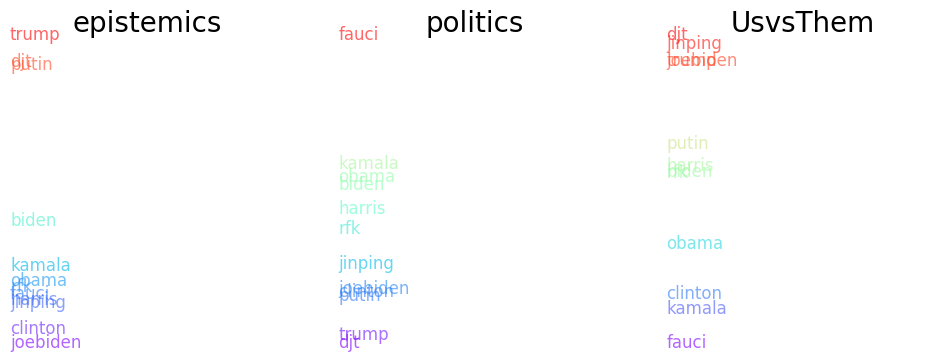

In [ ]:
# Visualizing politicians' projections
def Coloring(Series):
    x = Series.values
    y = x-x.min()
    z = y/y.max()
    c = list(plt.cm.rainbow(z))
    return c

def PlotDimension(ax,df, dim):
    ax.set_frame_on(False)
    ax.set_title(dim, fontsize = 20)
    colors = Coloring(df[dim])
    for i, word in enumerate(df.index):
        ax.annotate(word, (0, df[dim][i]), color = colors[i], alpha = 0.6, fontsize = 12)
    MaxY = df[dim].max()
    MinY = df[dim].min()
    plt.ylim(MinY,MaxY)
    plt.yticks(())
    plt.xticks(())

fig = plt.figure(figsize = (12,4))
ax1 = fig.add_subplot(131)
PlotDimension(ax1, poldf, 'epistemics')
ax2 = fig.add_subplot(132)
PlotDimension(ax2, poldf, 'politics')
ax3 = fig.add_subplot(133)
PlotDimension(ax3, poldf, 'UsvsThem')
plt.show()

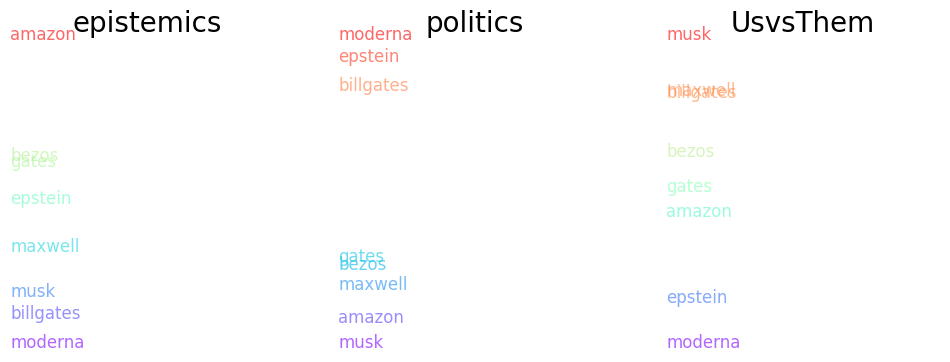

In [ ]:
# Visualizing business-related projections
def Coloring(Series):
    x = Series.values
    y = x-x.min()
    z = y/y.max()
    c = list(plt.cm.rainbow(z))
    return c

def PlotDimension(ax,df, dim):
    ax.set_frame_on(False)
    ax.set_title(dim, fontsize = 20)
    colors = Coloring(df[dim])
    for i, word in enumerate(df.index):
        ax.annotate(word, (0, df[dim][i]), color = colors[i], alpha = 0.6, fontsize = 12)
    MaxY = df[dim].max()
    MinY = df[dim].min()
    plt.ylim(MinY,MaxY)
    plt.yticks(())
    plt.xticks(())

fig = plt.figure(figsize = (12,4))
ax1 = fig.add_subplot(131)
PlotDimension(ax1, bizdf, 'epistemics')
ax2 = fig.add_subplot(132)
PlotDimension(ax2, bizdf, 'politics')
ax3 = fig.add_subplot(133)
PlotDimension(ax3, bizdf, 'UsvsThem')
plt.show()

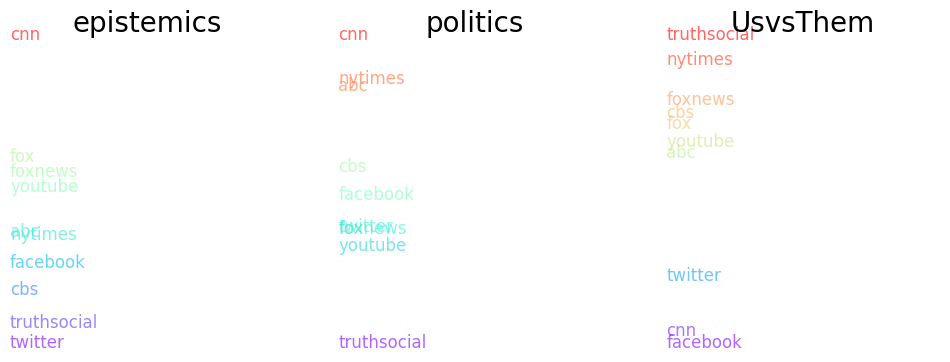

In [ ]:
# Visualizing projections of media-related actors
def Coloring(Series):
    x = Series.values
    y = x-x.min()
    z = y/y.max()
    c = list(plt.cm.rainbow(z))
    return c

def PlotDimension(ax,df, dim):
    ax.set_frame_on(False)
    ax.set_title(dim, fontsize = 20)
    colors = Coloring(df[dim])
    for i, word in enumerate(df.index):
        ax.annotate(word, (0, df[dim][i]), color = colors[i], alpha = 0.6, fontsize = 12)
    MaxY = df[dim].max()
    MinY = df[dim].min()
    plt.ylim(MinY,MaxY)
    plt.yticks(())
    plt.xticks(())

fig = plt.figure(figsize = (12,4))
ax1 = fig.add_subplot(131)
PlotDimension(ax1, meddf, 'epistemics')
ax2 = fig.add_subplot(132)
PlotDimension(ax2, meddf, 'politics')
ax3 = fig.add_subplot(133)
PlotDimension(ax3, meddf, 'UsvsThem')
plt.show()

In [ ]:
# 